# Notebook exemplo de modelo de predição de preços de ações

## Imports

In [ ]:
# =================================================================== #
# Previsão de Preço de Ação (Exemplo Didático)                        #
# =================================================================== #
# Objetivo: Mostrar como treinar um modelo de machine learning        #
# para prever o preço de fechamento de uma ação com base em features  #
# derivadas de séries temporais.                                      #
# =================================================================== #

In [1]:
# --- 1. Importação de bibliotecas ---
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


In [2]:
# --- 2. Download de dados da ação ---
# Exemplo: Petrobras (PETR4.SA) de 2018 até hoje
ticker = "PETR4.SA"
df = yf.download(ticker, start="2018-01-01")

/tmp/ipykernel_13440/2828277055.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2018-01-01")
[*********************100%***********************]  1 of 1 completed


In [3]:
# --- 3. Engenharia de atributos (features) ---
# Criando variáveis explicativas com base nos preços passados
df["Return"] = df["Close"].pct_change()
df["Volatility"] = df["Return"].rolling(window=10).std()
df["MA_7"] = df["Close"].rolling(window=7).mean()
df["MA_21"] = df["Close"].rolling(window=21).mean()
df["EMA_7"] = df["Close"].ewm(span=7, adjust=False).mean()
df["EMA_21"] = df["Close"].ewm(span=21, adjust=False).mean()
df["Momentum"] = df["Close"] - df["Close"].shift(5)
df = df.dropna()

In [4]:
df

Price,Close,High,Low,Open,Volume,Return,Volatility,MA_7,MA_21,EMA_7,EMA_21,Momentum
Ticker,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,,,,,,,
Date,,,,,,,,,,,,
2018-01-30,5.356645,5.433601,5.320916,5.433601,46203000,-0.018136,0.025452,5.287150,4.930381,5.291077,5.019247,0.343551
2018-01-31,5.414361,5.477575,5.408865,5.425355,41576600,0.010775,0.023203,5.335443,4.971607,5.321898,5.055166,0.098944
2018-02-01,5.639731,5.667216,5.430852,5.430852,51950200,0.041624,0.024850,5.424963,5.021601,5.401356,5.108308,0.324314
2018-02-02,5.488570,5.612248,5.455589,5.579267,50657800,-0.026803,0.027682,5.449699,5.064005,5.423160,5.142878,0.010994
2018-02-05,5.232966,5.488568,5.232966,5.400619,62268600,-0.046570,0.032795,5.437920,5.092929,5.375611,5.151068,-0.222624
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-08,30.650000,31.080000,30.500000,31.080000,17687400,-0.005838,0.005067,31.017142,31.460952,31.017179,31.246734,-0.730000
2025-10-09,30.209999,30.840000,30.190001,30.660000,22879700,-0.014356,0.005680,30.838571,31.399047,30.815384,31.152485,-0.870001


Text(0.5, 1.0, 'PETR4.SA Price with Moving Averages')

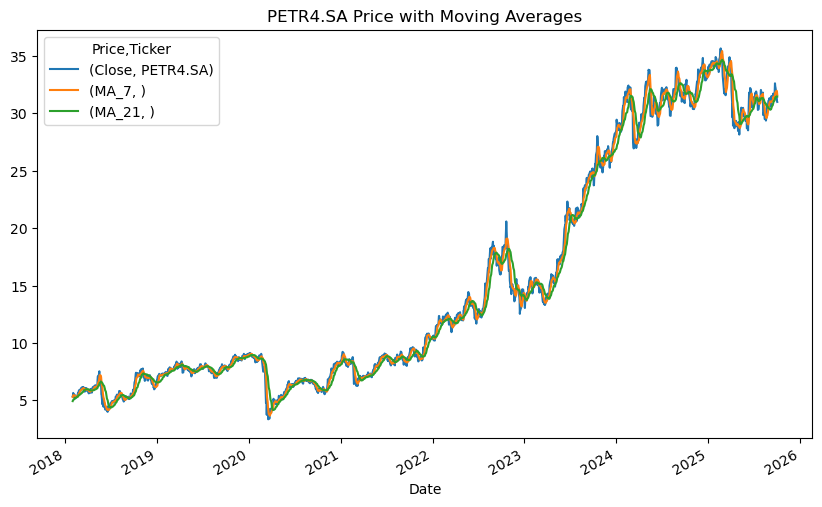

In [10]:
df[["Close", "MA_7", "MA_21"]].plot(figsize=(10, 6))
plt.title(f"{ticker} Price with Moving Averages")

In [11]:
# --- 4. Definição das variáveis dependente (y) e independentes (X) ---
X = df[["Return", "Volatility", "MA_7", "MA_21", "EMA_7", "EMA_21", "Momentum"]]
y = df["Close"]

# --- 5. Separação treino/teste ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# --- 6. Treinamento do modelo ---
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# --- 7. Avaliação ---
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erro Médio Absoluto (MAE): {mae:.2f}")
print(f"R²: {r2:.2f}")

c:\Users\amilt\anaconda3\envs\proj_materials_stock_env\Lib\site-packages\sklearn\utils\validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
c:\Users\amilt\anaconda3\envs\proj_materials_stock_env\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\amilt\anaconda3\envs\proj_materials_stock_env\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
c:\Users\amilt\anaconda3\envs\proj_materials_stock_env\Lib\site-packages\sklearn\utils\validation.py:767: FutureWarning:

Erro Médio Absoluto (MAE): 0.83
R²: 0.49


c:\Users\amilt\anaconda3\envs\proj_materials_stock_env\Lib\site-packages\sklearn\utils\validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
c:\Users\amilt\anaconda3\envs\proj_materials_stock_env\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\amilt\anaconda3\envs\proj_materials_stock_env\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
c:\Users\amilt\anaconda3\envs\proj_materials_stock_env\Lib\site-packages\sklearn\utils\validation.py:767: FutureWarning:

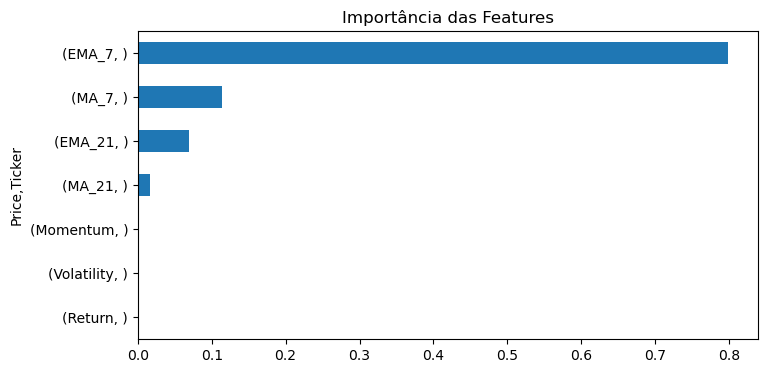

In [12]:
# --- 8. Importância das features ---
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh", figsize=(8,4), title="Importância das Features")
plt.show()

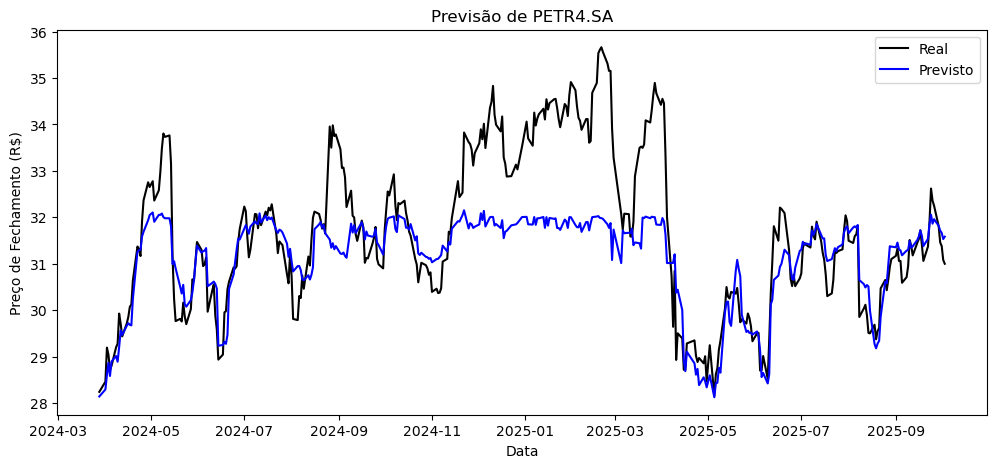

In [13]:
# --- 9. Comparação visual ---
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label="Real", color="black")
plt.plot(y_test.index, y_pred, label="Previsto", color="blue")
plt.title(f"Previsão de {ticker}")
plt.xlabel("Data")
plt.ylabel("Preço de Fechamento (R$)")
plt.legend()
plt.show()

# --- 10. Observações finais ---
# Este modelo é apenas ilustrativo e não deve ser usado para decisões reais de investimento.
# O foco é didático — para mostrar como séries temporais podem ser transformadas
# em features para um modelo de machine learning supervisionado.